In [14]:
import numbers
import numpy as np
import pandas as pd
from pathlib import Path
from io import BytesIO
import sys
import json
import pprint
from mplsoccer import Pitch
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Literal
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.lines as mlines
import math
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import image
from datetime import date, datetime
from matplotlib.colors import PowerNorm
from matplotlib.lines import Line2D
from soccerplots.radar_chart import Radar
from mplsoccer import grid


matchids = [1886347, 1899585, 1925299, 1953632, 1996435, 2006229, 2011166, 2013725,
2015213, 2017461]



 

In [4]:

#Previously created classes for final proj. Will rewrite useful xpass stuff in below class. Going to reuse dataloader from here since that is only really applicable to me

class Validators:

    @staticmethod
    def ensure_list_of_ints(input_val: int | list[int]) -> list[int]:
        if isinstance(input_val, int):
            return [int(input_val)]   
        if isinstance(input_val, list):
            if all(isinstance(x, numbers.Integral) for x in input_val):
                return [int(x) for x in input_val]
            else:
                raise TypeError('You passed a list (good!), but not all values were integers')

        raise TypeError(f'You must pass a list or int. You passed {type(input_val)}')
    
    @staticmethod
    def ensure_player_id_int(input_val: int):
        if isinstance(input_val, int):
            return input_val
        else:
            raise TypeError(f'You must pass an int. You passed {type(input_val)}')

class DataLoaderSingleMatch:
    def __init__(self, match_id: int):
        self.match_id: int = match_id
    
    def dynamic_events_path(self) -> str:
        return f'{self.match_id}/{self.match_id}_dynamic_events.csv'
    @property
    def match_info_file_name(self) -> str:
        return f'{self.match_id}/{self.match_id}_match.json'
    
    def load_match_info(self) -> pd.DataFrame:
        with open(self.match_info_file_name) as f:
            match_dict = json.load(f)
            df = pd.json_normalize(match_dict)
        return df  
    
class DataLoader:
    def __init__(self, match_ids: int | list[int]) -> None:
        self.match_ids: list[int] = Validators.ensure_list_of_ints(match_ids)

    xx_test_matchids = (1886347, 1899585, 1925299, 1953632, 1996435, 2006229, 2011166, 2013725, 2015213, 2017461)

    @classmethod
    def data_loader_single_match(cls, match_id: int):
        file_name= DataLoaderSingleMatch(match_id).dynamic_events_path()
        match: pd.DataFrame = pd.read_csv(file_name, low_memory= False)
        return match

    def data_loader_multi_match(self, match_ids = None) -> pd.DataFrame:
        
        if match_ids == None: match_ids = self.match_ids

        all_match_dfs: list[pd.DataFrame] = []
        for match_id in match_ids:
            match: pd.DataFrame = self.data_loader_single_match(match_id = match_id)
            all_match_dfs.append(match)
        all_matches= pd.concat(all_match_dfs, ignore_index =True)
        return all_matches

    def data_loader_single_json(self, match_id: int) -> pd.DataFrame:
        obj = DataLoaderSingleMatch(match_id=match_id)
        return obj.load_match_info()

    def data_loader_multi_json(self, match_ids = None):
        if match_ids == None: match_ids = self.match_ids
        objs: list[DataLoaderSingleMatch] = []
        for i in match_ids:
            objs.append(DataLoaderSingleMatch(i))
        list1 = []
        for obj in objs:
            list1.append(obj.load_match_info())
        df = pd.concat(list1)
        return df
    
class FieldZone:

    zone_values: dict[int, tuple[str, str]] = {
            1: ("depth_1", "width_left"),
            2: ("depth_1", "width_center"),
            3: ("depth_1", "width_right"),
            4: ("depth_2", "width_left"),
            5: ("depth_2", "width_center"),
            6: ("depth_2", "width_right"),
            7: ("depth_3", "width_left"),
            8: ("depth_3", "width_center"),
            9: ("depth_3", "width_right"),
            10: ("depth_4", "width_left"),
            11: ("depth_4", "width_center"),
            12: ("depth_4", "width_right"),
            13: ("depth_5", "width_left"),
            14: ("depth_5", "width_center"),
            15: ("depth_5", "width_right"),
            16: ("depth_6", "width_left"),
            17: ("depth_6", "width_center"),
            18: ("depth_6", "width_right"),
            19: ("depth_5", "half_space_left"),
            20: ("depth_5", "half_space_right"),
        }

    def __init__(self, df_data: pd.DataFrame) -> None:
        self.df_data: pd.DataFrame = df_data


    def get_depth_mask(self, depth_term: str) -> pd.Series:
        x_starts: pd.Series[float] = self.df_data['x_start']
        match depth_term:
            case 'depth_1':
                return x_starts <= -35.34
            case 'depth_2':
                return x_starts.between(-35.34, -17.66, inclusive= 'right')
            case 'depth_3':
                return x_starts.between(-17.66, 0, inclusive = 'right')
            case 'depth_4':
                return x_starts.between(0, 17.66, inclusive = 'right')
            case 'depth_5':
                return x_starts.between(17.66, 35.34, inclusive = 'right')
            case 'depth_6':
                return x_starts >= 35.34
            case _:
                raise ValueError('You did not pass a valid depth term')
            

    def get_width_mask(self, width_term: str) -> pd.Series:
        y_starts: pd.Series[float] = self.df_data['channel_id_start']
        match width_term:
            case 'width_left':
                return y_starts.isin([1,2])
            case 'width_center':
                return y_starts == 3
            case 'width_right':
                return y_starts.isin([4,5])
            case 'half_space_left':
                return y_starts == 2
            case 'half_space_right':
                return y_starts == 4
            case _:
                raise ValueError('You did not pass a valid width term')
    



    def get_zone_defined_possessions(self, zone: int) -> pd.DataFrame:
        """
        Input a dataframe of dynamic events data and in integer between 1 and 20. Returns all possessions in static possession that begin in that zone.
        Zones defined as such: https://learning.coachesvoice.com/wp-content/webpc-passthru.php?src=https://learning.coachesvoice.com/wp-content/uploads/2022/05/Tactics1.png&nocache=1
        Input 19 for the left attacking half space, and 20 for the right attacking half space

        Composite key for each record: 'match_id' and 'event_id'
        """
        data = self.df_data.copy()
        #Keep only player possessions
        is_possession: pd.Series[bool] = data['event_type'] == 'player_possession'
        #Keep only possessions vs blocks
        is_vs_block: pd.Series[bool] = data['team_out_of_possession_phase_type'].isin(['high_block', 'medium_block','low_block'])
  
        depth = self.get_depth_mask(self.zone_values[zone][0])

        width = self.get_width_mask(self.zone_values[zone][1])

        mask = is_possession & is_vs_block & depth & width
        
        filtered_df = data.loc[mask].copy()

        return filtered_df
    
    def get_zone_summary(self, zone: int):
    ### aggregator
        
        summary = (
            self.get_zone_defined_possessions(zone)
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                total_actions= ('player_name', 'count')
                )
        
        )
        minutes_counts = PlayerInfo(self.df_data).get_player_info()
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['ta/90'] = summary['total_actions']/(summary['total_minutes']/90)
        summary = summary.sort_values('ta/90', ascending = False)
        return summary

class PlayerInfo:
    
    @staticmethod
    def age_from_datetime(series: pd.Series) -> pd.Series:
        """
        Calculate age in years from a pandas datetime64[ns] Series.
        """
        today = pd.Timestamp.today().normalize()

        age = today.year - series.dt.year

        had_birthday = (
            (today.month > series.dt.month) |
            ((today.month == series.dt.month) & (today.day >= series.dt.day))
        )

        return age - (~had_birthday).astype(int)
        
   
    def __init__(self, df_data: pd.DataFrame):
            df_data['match_id'] = df_data['match_id'].astype(int)
            self.df_data = df_data

    def list_from_df(self):
        list1 = []
        for id in self.df_data['match_id'].unique():
            list1.append(id)
        return list1
    
    def get_info_df(self):
        list1 = self.list_from_df()
        dl = DataLoader(list1)
        df_data = dl.data_loader_multi_json()
    
        all_players = []

        for _, row in df_data.iterrows():
            players = pd.json_normalize(row['players'], sep='>')
            all_players.append(players)

        df_players = pd.concat(all_players, ignore_index=True)
        df_players['birthday'] = pd.to_datetime(df_players['birthday'], errors='coerce')

        return df_players
    
    def get_player_info(self):
        df_data = self.get_info_df()
        

        out = (
            df_data
            .groupby('id')
            .agg(
                total_minutes=('playing_time>total>minutes_played', 'sum'),
                total_minutes_tip=('playing_time>total>minutes_tip', 'sum'),
                total_minutes_otip=('playing_time>total>minutes_otip', 'sum'),
                positions=('player_role>acronym',lambda x: sorted(set(x))),
                birthday=('birthday', 'first')  
            )
            .rename_axis('player_id')
        )
        
        out['age'] = PlayerInfo.age_from_datetime(out['birthday'])
        out = out.drop(columns='birthday')

      

 
        return out
    
    def get_player_matchids(self, player_id):
    
        player_df = self.df_data[self.df_data['player_id'] == player_id]

        ids = player_df['match_id'].unique()

        return ids
       
class PassingStats:

    def __init__(self, df_data: pd.DataFrame):
        self.df_data = df_data

    def prepare_dataframe_xpass(self):
        self.df_data = self.df_data[self.df_data['event_type_id'] == 8]
        self.df_data = self.df_data[self.df_data['pass_outcome_id'].isin([1,2])]
        
        return self.df_data

    def add_xpass_columns(self):
    
        self.df_data = self.df_data.copy()
        self.prepare_dataframe_xpass()
        self.df_data = self.df_data[self.df_data['player_targeted_xpass_completion'].notnull()]

        self.df_data['pass_success'] = (self.df_data['pass_outcome_id'] == 1).astype('Int64')
      

        self.df_data['pass_completion_vs_expected'] = (
            self.df_data['pass_success'] - self.df_data['player_targeted_xpass_completion']
        )

        return self.df_data

    def get_xpass_summary(self):
        self.df_data = self.add_xpass_columns()

        summary = (
            self.df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                pass_completion_vs_expected=('pass_completion_vs_expected', 'sum'),
                expected_passes_completed = ('player_targeted_xpass_completion', 'sum'),
                total_passes=('player_name', 'count'),
                completed_passes = ('pass_success', 'sum'),
                difficult_passes=('player_targeted_difficult_pass_target', 'sum')
            )
        )

        return summary.sort_values('pass_completion_vs_expected', ascending=False)
    
    def get_player_xpass(self, player_id: int) -> pd.DataFrame:
        self.player_id =  Validators.ensure_player_id_int(player_id)

        summary = self.get_xpass_summary()

        try:
            player_row = summary.loc[player_id]
        except:
            raise KeyError(f"Player ID {player_id} not found in xPass summary.")
        
        return player_row

    def get_xpass_viz(self, player_id):
        xpass = self.add_xpass_columns()
        xpass = xpass[xpass['player_id'] == player_id]
        
       

        pitch = Pitch(pitch_type='skillcorner', pitch_length=106, pitch_width=68,
              axis=True, label=False)
        fig, ax = pitch.draw()

        cmap = plt.get_cmap('jet')

        for event in range(len(xpass)):
            row = xpass.iloc[event]
            if row['pass_outcome_id'] == 1:
                ax.plot(
                (row['x_end'], row['player_targeted_x_reception']),
                (row['y_end'], row['player_targeted_y_reception']),
                color= cmap(row['player_targeted_xpass_completion']), ls='solid'
                )
            elif row['pass_outcome_id'] == 2:
                ax.plot(
                (row['x_end'], row['player_targeted_x_pass']),
                (row['y_end'], row['player_targeted_y_pass']),
                color=cmap(row['player_targeted_xpass_completion']), ls='dashed'
                )

            ax.scatter(row['x_end'], row['y_end'], color = cmap(row['player_targeted_xpass_completion']), s=15, zorder=5)

            
        name: str = xpass['player_name'].unique()[0]
        
        plt.title('Pass map for ' + name)

        norm = Normalize(vmin=0, vmax=1)
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("Expected Pass Completion")

        solid_line = mlines.Line2D([], [], color='black', linestyle='-',
                           label='Successful pass')
        dashed_line = mlines.Line2D([], [], color='black', linestyle='--',
                            label='Unsuccessful pass')

        ax.legend(handles=[solid_line, dashed_line],
            loc='lower center',
            bbox_to_anchor=(0.5, 1.05),   # X center, Y above axis
            frameon=False,
            ncol=2)
        return pitch
        
class ZoneMovers:
    bins = [-1000, -35.34, -17.66, 0, 17.66, 35.34, 1000]
    labels = [1, 2, 3, 4, 5, 6]
    
    def __init__(self, df_data: pd.DataFrame):
        self.df_data = df_data
    
    def get_zone_movers_carries(self, filter:bool = False):
        """
        input a dynamic events df, output a df with a zones_moved_forward field. Only considers zone moving carries Zones moved forwards are positive, zones moved backwards are negative

        if filter = True, returns a df of only zone moving carries. If false, returns a df of all player possessions with added zone mover columns
        """
  
        data = self.df_data.copy()
        
        moving = data.loc[data['event_type'] == 'player_possession'].copy()

        x_start_bucket = pd.cut(moving['x_start'], bins=ZoneMovers.bins, labels=ZoneMovers.labels)
        x_end_bucket   = pd.cut(moving['x_end'], bins=ZoneMovers.bins, labels=ZoneMovers.labels)


        moving['x_start_bucket'] = x_start_bucket.astype('int64')
        moving['x_end_bucket']   = x_end_bucket.astype('int64')

        moving['zones_moved_forward'] = x_end_bucket.astype('int64') - x_start_bucket.astype('int64')

        if filter is True:
            moving = moving.loc[moving['zones_moved_forward'] != 0]

        return moving
    
    def get_zone_movers_passes(self, filter:bool = False):

        data = self.df_data.copy()
        moving = data.loc[data['event_type'] == 'player_possession'].copy()
        moving = moving.loc[moving['player_targeted_x_reception'].isna() == False].copy()

        x_start_bucket = pd.cut(moving['x_end'], bins=ZoneMovers.bins, labels=ZoneMovers.labels)
        x_end_bucket   = pd.cut(moving['player_targeted_x_reception'], bins=ZoneMovers.bins, labels=ZoneMovers.labels)

   
        moving['pass_zone'] = x_start_bucket.astype(int)
        moving['reception_zone'] = x_end_bucket.astype(int)

    
        zones_moved_forward = moving['reception_zone'] - moving['pass_zone']
        zones_moved_forward = zones_moved_forward.fillna(0).astype(float)
        moving['zones_moved_forward'] = zones_moved_forward.astype(int)
        if filter is True:
            moving = moving.loc[moving['zones_moved_forward'] != 0]

        return moving
    
    def get_zone_movers_summary_helper(self, type_: str = 'pass'):
    
        data = self.df_data.copy()
        if type_ == 'pass':
                df = self.get_zone_movers_passes()
        elif type_ == 'carry':
                df = self.get_zone_movers_carries()
        else:
            raise ValueError('type_ must be pass, carry, or both')
        summary = (
            df
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                zones_moved = ('zones_moved_forward', 'sum'))
        )
        info = PlayerInfo(data)
        minutes_counts = info.get_player_info()
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['zm/90'] = summary['zones_moved']/(summary['total_minutes']/90)
        summary = summary.sort_values('zm/90', ascending = False)
    
        return summary
    
    def get_zone_movers_summary(self, type_: str = 'pass'):

        """
        Generates zone mover summary from Dynamic Events dataframe. 

        Accepts a dataframe of dynamic events and a string reading "pass", "carry", or "both" to determine type
        """
        
        if type_ == 'pass':
            summary = self.get_zone_movers_summary_helper('pass')
        elif type_ == 'carry':
            summary = self.get_zone_movers_summary_helper('carry')
        elif type_ == 'both':
            df1 = self.get_zone_movers_summary_helper('pass')
            df2 = self.get_zone_movers_summary_helper('carry')
            summary = df1.merge(df2, on = ['player_id', 'player_name','total_minutes'], how = 'left')
            columns_drop = ( ['positions_y'])
            summary = summary.drop(columns_drop, axis = 1)
            new_order = [	'player_name', 'total_minutes', 'positions_x' ,	'zones_moved_x', 	'zm/90_x',	'zones_moved_y',	'zm/90_y']
            summary = summary.reindex(columns=new_order)
            summary.rename(columns={'positions_x': 'positions', 'zones_moved_x' : 'zones_moved_passing', 'zones_moved_y' : 'zones_moved_carrying',
                                'zm/90_x' : 'zmp/90', 'zm/90_y' : 'zmc/90'}, inplace=True)
            summary['zones_moved'] = summary['zones_moved_passing'] + summary['zones_moved_carrying']
            summary['zm/90'] = summary['zmp/90'] + summary['zmc/90']
            summary = summary.sort_values('zm/90', ascending = False)
        else: 
            raise ValueError('type_ must be pass, carry, or both')
        

        return summary
    

    def get_zone_movers_viz(self, player_id: int):
        """
        takes a SkillCorner dynamic events df and a playerid
        generates a pitch visualization of a player's (successful) zone movers in a given df
        green dashed lines are passes, red solid lines are runs with the ball

        needs matplotlib pyplot, seaborn, mplsoccer
        """
        
        passes  = self.get_zone_movers_passes(True)

        carries = self.get_zone_movers_carries(True)

    
        pp = passes.loc[passes['player_id'] == player_id]
        pc = carries.loc[carries['player_id'] == player_id]

  
        pitch = Pitch(pitch_type='skillcorner', pitch_length=106, pitch_width=68,
                axis=True, label=True, positional=True, shade_middle=True)
        fig, ax = pitch.draw()

        for event in range(len(pp)):
            row = pp.iloc[event]
            ax.plot(
            (row['x_end'], row['player_targeted_x_reception']),
            (row['y_end'], row['player_targeted_y_reception']),
            color='green', ls='dashed'
            )

            ax.scatter(row['x_end'], row['y_end'], color='green', s=40, zorder=5)

        for event in range(len(pc)):
            row = pc.iloc[event]
            ax.plot(
            (row['x_start'], row['x_end']),
            (   row['y_start'], row['y_end']),
            color='red'
            )

            ax.scatter(row['x_start'], row['y_start'], color='red', s=40, zorder=5)
    
        name: str = pp['player_name'].unique()[0]
        plt.title('Zone mover map for ' + name)

    
        return pitch


In [41]:
class ASIProjMetrics:

    """
    Create a suite of passing metrics for the Adam Wharton section. Focusing on progression, chance creation, risk taking, and high importance passing. 

    Metrics completed: Xpass,  Xthreat added passing, line breaks, SkillCorner Difficult Passes (%?), forward passes, takes most threatening option, chances created/sca

    """
    AGG_REGISTRY = {
        'xthreat_added_passing_aggregator': ['player_name', 'xthreat_added_per_pass', 'xthreat_added_passing_per_90'],
        'line_breaking_passes_aggregator': ['lines_broken_per_90'],
        'shot_creating_aggregator': ['passes_leading_to_shot_per_90', 'shot_creating_actions_per_90'],
        'miscellaneous_stats_aggregator' : ['percent_dangerous_passes', 'percent_difficult_passes', 'percent_forward_passes', 'pass_completion_percentage'],
        #'xpass_summary_aggregator' : ['pass_completion_vs_expected']
        'progressive_aggregator': ['ppd_per_90']
    }

    POS_REGISTRY = {'LDM','DM','RDM','CM'}

  

    def __init__(self, df_data: pd.DataFrame):
         self.df_data: pd.DataFrame = df_data
         self.player_info: pd.DataFrame = PlayerInfo(df_data).get_player_info()

    def select_passes(self, completed: str = 'both'):
        """
        Input str of 'true', 'false', or 'both', output df filtered passes of the specified outcome. Defaults to both. 
        """
        df_data = self.df_data.copy()
        df_data = df_data[df_data['event_type_id'] == 8]
        df_data['result_of_next_pp'] = df_data['end_type_id'].shift(-1)
        if completed == 'both':
            df_data = df_data[df_data['pass_outcome_id'].isin([1,2])]
        elif completed == 'true':
            df_data = df_data[df_data['pass_outcome_id'] == 1]
        elif completed == 'false':
            df_data = df_data[df_data['pass_outcome_id'] == 2]
        else: 
            raise ValueError(f'completed must be a str of true, false, or both. You input a {type(completed)} which reads {completed}.')
        return df_data

    def xthreat_added_passing_aggregator(self):
        """
        Aggregate data based on player expected threat added passing
        """
        df_data = self.select_passes('true')

        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                xthreat_added_passing = ('player_targeted_xthreat', 'sum'),
                xthreat_added_per_pass = ('player_targeted_xthreat', 'mean')
            )
        )
        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        #summary['xthreat_added_passing_per_90'] = summary['xthreat_added_passing']/(summary['total_minutes']/90)
        summary['xthreat_added_passing_per_90'] = summary['xthreat_added_passing']/(summary['total_minutes_tip']/30)
    
        return summary.sort_values('xthreat_added_passing_per_90', ascending = False)
    
    def line_breaking_passes_aggregator(self, type = 'through'):
        """
        Aggregate data based on player line breaking passing. Insert a string of 'through' if only 'through' line breakers are desired.
        """

        df_data = self.select_passes('true')

        lines_broken = df_data['first_line_break'] + df_data['second_last_line_break'] + df_data['last_line_break'] 
        df_data['lines_broken'] = lines_broken

        if type == 'through':
            df_data = df_data[df_data['furthest_line_break_type_id'] == 1]

        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                lines_broken = ('lines_broken', 'sum'),
                passes = ('player_name', 'count')
            )
        )
        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['lines_broken_per_90'] = summary['lines_broken']/(summary['total_minutes_tip']/30)
        summary.fillna(0.0)

        return summary.sort_values('lines_broken_per_90', ascending = False)

    
    def miscellaneous_stats_aggregator(self):
        
        df_data = self.select_passes('both')

        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                percent_dangerous_passes = ('player_targeted_dangerous', 'mean'),
                percent_difficult_passes = ('player_targeted_difficult_pass_target', 'mean'),
                percent_forward_passes = (('pass_direction_id', lambda s: s.eq(1).mean())),
                passes = ('player_name', 'count'),
                pass_completion_percentage = ('pass_outcome_id',lambda s: s.eq(1).mean()),
                percent_give_and_go = ('initiate_give_and_go', 'mean'),
                percent_finish_and_create = ('team_in_possession_phase_type_id', lambda s: s.isin([1,2]).mean())
            )
        )

       
        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['passes_per_90'] = summary['passes']/(summary['total_minutes_tip']/30)

        return summary.sort_values('percent_forward_passes', ascending= False)

    def miscellaneous_stats_aggregator(self):
        
        df_data = self.select_passes('both')

        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                percent_dangerous_passes = ('player_targeted_dangerous', 'mean'),
                percent_difficult_passes = ('player_targeted_difficult_pass_target', 'mean'),
                percent_forward_passes = (('pass_direction_id', lambda s: s.eq(1).mean())),
                passes = ('player_name', 'count'),
                pass_completion_percentage = ('pass_outcome_id',lambda s: s.eq(1).mean()),
                percent_give_and_go = ('initiate_give_and_go', 'mean'),
                percent_finish_and_create = ('team_in_possession_phase_type_id', lambda s: s.isin([1,2]).mean())
            )
        )

       
        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['passes_per_90'] = summary['passes']/(summary['total_minutes_tip']/30)

        return summary.sort_values('percent_forward_passes', ascending= False)
    
    def progressive_aggregator(self):

        df_data = self.select_passes('true')

        df_data['progressive_distance'] = df_data['player_targeted_x_reception'] - df_data['x_end'] 
        df_data['progressive_distance'] = df_data['progressive_distance'].clip(lower=0.0)
        
        
        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                progressive_passing_distance = ('progressive_distance', 'sum'),
                shot_creating_actions = ('result_of_next_pp', lambda s: s.eq(2).sum())
            )
        )

        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['ppd_per_90'] = summary['progressive_passing_distance']/(summary['total_minutes_tip']/30)
        
        return summary.sort_values('ppd_per_90', ascending= False)
     

    def shot_creating_aggregator(self):
        
        df_data = self.select_passes('true')


        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                passes_leading_to_shot = ('lead_to_shot', 'sum'),
                shot_creating_actions = ('result_of_next_pp', lambda s: s.eq(2).sum())
            )
        )
        
        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['passes_leading_to_shot_per_90'] = summary['passes_leading_to_shot']/(summary['total_minutes_tip']/30)
        summary['shot_creating_actions_per_90'] = summary['shot_creating_actions']/(summary['total_minutes_tip']/30)
        return summary.sort_values('shot_creating_actions_per_90', ascending= False)
    
    def xpass_summary_aggregator(self):
        df_data = PassingStats(self.df_data).add_xpass_columns().copy()

        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                pass_completion_vs_expected=('pass_completion_vs_expected', 'sum')
            )
        )

        return summary.sort_values('pass_completion_vs_expected', ascending=False)
                      

    def build_overall_aggregator(self):
        """
        Possible positions:
        GK,LB,LWB,LCB,CB,RCB,RWB,RB,LDM,DM,RDM,LM,CM,RM,AM,LW,RW,LF,CF,RF    
        """
        features = pd.concat(
            [
                getattr(self, method)()[cols]
                for method, cols in self.AGG_REGISTRY.items()
            ],
            axis=1
        )
        minutes_counts = self.player_info
        features = features.merge(minutes_counts, on = ['player_id'], how = 'left')

        mask = features['positions'].apply(
            lambda pos: bool(self.POS_REGISTRY & set(pos))
        )

        
        out = features.loc[mask].copy()

        num_cols = out.select_dtypes(include="number").columns
        out[num_cols] = out[num_cols].fillna(0.0)

        return out
    
    def format_aggregator(self):
        agg = self.build_overall_aggregator()

        agg = agg.astype({'lines_broken_per_90' : np.float64, 'age': np.int64})

        order = ['player_name', 'age', 'positions', 'total_minutes', 'xthreat_added_passing_per_90', 'xthreat_added_per_pass',	'passes_leading_to_shot_per_90',	'shot_creating_actions_per_90','lines_broken_per_90', 'ppd_per_90', 'pass_completion_percentage']	
        agg = agg[order]

        agg['positions'] = (
        agg['positions']
        .astype(str)
        .str.replace(r"[\[\]']", "", regex=True)
        )

        rate_cols = [
            'ppd_per_90',
        'lines_broken_per_90',
        'passes_leading_to_shot_per_90',
        'shot_creating_actions_per_90'
            ]       

        agg[rate_cols] = (
        agg[rate_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
            )
        
        
        return agg
    
class ASIProjMetricsDefense:

    """
    Create Defensive metrics for the ASI Wharton project. Focus on aggressive defending

    Metrics in progress: Possession loss leading to shot, Direct/indirect regain, What is xloss?
    """

    POS_REGISTRY = {'LDM','DM','RDM','CM'}

    def __init__(self, df_data: pd.DataFrame):
        self.df_data: pd.DataFrame = df_data
        self.player_info: pd.DataFrame = PlayerInfo(df_data).get_player_info()

    def select_engagements(self):
        df_data = self.df_data.copy()

        df_data = df_data[df_data['event_type_id'] == 9]

        return df_data
    
    def pressures_summary_aggregator(self):
        """
       
        don't need to look into subtype, engagements per 30 tip, (active), stop or reduce danger (pretty good), 
         
        7 direct regain
        8 indirect regain
        9 direct disruption
        10 indirect regain
        """

        df_data = self.select_engagements()

        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                direct_regains = ('end_type_id', lambda x: x.eq(7).sum()),
                indirect_regains = ('end_type_id', lambda x: x.eq(8).sum()),
                direct_disruptions = ('end_type_id', lambda x: x.eq(9).sum()),
                indirect_disruptions = ('end_type_id', lambda x: x.eq(10).sum())

            )
        )

        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['direct_regains/90'] = summary['direct_regains']/(summary['total_minutes']/90)
        summary['indirect_regains/90'] = summary['indirect_regains']/(summary['total_minutes']/90)
        summary['direct_disruptions/90'] = summary['direct_disruptions']/(summary['total_minutes']/90)
        summary['indirect_disruptions/90'] = summary['indirect_disruptions']/(summary['total_minutes']/90)
        

        return summary.sort_values('direct_regains/90', ascending=False)
        
class ASIProjViz:


    colors = {
        'color1' : '#E63946',
        'color2' : '#F1FAEE',
        'color3' : '#A8DADC',
        'color4' : '#457B9D',
        'color5' : '#1D3557'
    }

    style_map = {
    1: dict(color="red"),   #line breaker
    2: dict(color="black"), #dangerous (TRUE if the probability of a goal being scored in the next 10s after the pass was completed is about 2%.)
    3: dict(color="green"), #both
    }
    
    def __init__(self, df_data: pd.DataFrame):
        self.df_data: pd.DataFrame = df_data
        self.player_info: pd.DataFrame = PlayerInfo(df_data).get_player_info()

    def get_passing_value_map(self, player_id, ax):
        """
        input player id, output line breaking (through), dangerous, and lead to shot passes by those two players, plotted and color coded. If an axis is provided, plots on that axis
        """
        plt.rcParams['text.color'] = StyleAggregator.text_color
        plt.rcParams['font.family'] = 'monospace' 
        
        df_data = self.df_data.copy()

        df_data = ASIProjMetrics(df_data).select_passes('true')

        df_data = df_data[df_data['player_id'] == player_id]
        
        forward_mask = df_data['pass_direction_id'] == 1
        line_break_mask = df_data['furthest_line_break_id'] == 1
        dangerous_mask = df_data['player_targeted_dangerous'] == True

        

        df_data = df_data[forward_mask | line_break_mask | dangerous_mask]
              
        pitch = Pitch(pitch_type='skillcorner', pitch_length=106, pitch_width=68, shade_middle=True)
        
        pitch.draw(ax=ax)

        for idx, row in df_data.iterrows():
            if dangerous_mask.loc[idx]:
                ax.plot(
                (row['x_end'], row['player_targeted_x_reception']),
                (row['y_end'], row['player_targeted_y_reception']),
                color =ASIProjViz.colors['color1']),
                pitch.arrows(
                row['x_end'],
                row['y_end'],
                row['player_targeted_x_reception'],
                row['player_targeted_y_reception'],
                ax=ax,
                color=ASIProjViz.colors['color1'],
                width=2,        # shaft thickness
                headwidth=4,    # arrow head width
                headlength=4,   # arrow head length
                zorder=5
                    )
            elif line_break_mask.loc[idx]:
                ax.plot(
                (row['x_end'], row['player_targeted_x_reception']),
                (row['y_end'], row['player_targeted_y_reception']),
                color=ASIProjViz.colors['color4']),
                pitch.arrows(
                row['x_end'],
                row['y_end'],
                row['player_targeted_x_reception'],
                row['player_targeted_y_reception'],
                ax=ax,
                color=ASIProjViz.colors['color4'],
                width=2,        # shaft thickness
                headwidth=4,    # arrow head width
                headlength=4,   # arrow head length
                zorder=6
                    )
            else:
                ax.plot(
                (row['x_end'], row['player_targeted_x_reception']),
                (row['y_end'], row['player_targeted_y_reception']),
                color='black'),
                pitch.arrows(
                row['x_end'],
                row['y_end'],
                row['player_targeted_x_reception'],
                row['player_targeted_y_reception'],
                ax=ax,
                color='black',
                width=2,        # shaft thickness
                headwidth=4,    # arrow head width
                headlength=4,   # arrow head length
                zorder=6
                    )
    


        name: str = df_data['player_name'].unique()[0]
        ax.text(0.5, 1.05, name, ha='center', va='bottom', transform=ax.transAxes, fontsize=12)


        
        
        ax.annotate(
            "",
            xy=(0.7, -0.05),        # tip
            xytext=(0.3, -0.05),    # tail
            xycoords="axes fraction",
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", lw=2, color="black"),
            )

        ax.text(
            0.5, -0.08,               # slightly below pitch
            "Direction of play",
            ha="center", va="top",
            transform=ax.transAxes,
            fontsize=12
            )
        return pitch
    
    def get_multi_pass_maps(self, player_ids: list[int]):

        # Create a 2x2 grid
        fig, axes = grid(
            figheight=10,
            nrows=2,
            ncols=2,
            space=0.05,
            axis=False
            )


        axes_flat = axes.flatten()

        for ax, pid in zip(axes_flat, player_ids):
            self.get_passing_value_map(pid, ax=ax)

        handles = [Line2D([0], [0], marker='o', color='w',
           label='Dangerous', markerfacecolor= ASIProjViz.colors['color1'], markersize=8),
        Line2D([0], [0], marker='o', color='w',
           label='Line Breaking', markerfacecolor = ASIProjViz.colors['color4'], markersize=8),
        Line2D([0], [0], marker='o', color='w',
           label='Forward', markerfacecolor = 'black', markersize=8),
            ]
        
        fig.legend(
            handles=handles,
            loc='upper center',
            ncol=3,
            frameon=False,
            fontsize=12,
            bbox_to_anchor=(0.5, .88)
            )

        fig.suptitle("Passing Value Maps: Selected Players", fontsize=16, y=0.51)
    
    def get_xthreat_map_viz(self, player_id):
        
        df_data = self.df_data.copy()
        
        
        norm = PowerNorm(
            gamma=0.35,
            vmin=0.0,
            vmax=0.04,
            clip=True
            )
        df_data = df_data[df_data['player_id']== player_id]
       

        pitch = Pitch(pitch_type='skillcorner', pitch_length=106, pitch_width=68,
            axis=True, label=False)
        fig, ax = pitch.draw()

        cmap = plt.get_cmap('RdYlGn')

        for event in range(len(df_data)):
            row = df_data.iloc[event]
            if row['pass_outcome_id'] == 1:
                ax.plot(
                (row['x_end'], row['player_targeted_x_reception']),
                (row['y_end'], row['player_targeted_y_reception']),
                color= cmap(norm(row['player_targeted_xthreat'])), ls='solid'
                )
            elif row['pass_outcome_id'] == 2:
                ax.plot(
                (row['x_end'], row['player_targeted_x_pass']),
                (row['y_end'], row['player_targeted_y_pass']),
                color=cmap(norm(row['player_targeted_xthreat'])), ls='dashed'
                )

            ax.scatter(row['x_end'], row['y_end'], color = cmap(norm(row['player_targeted_xthreat'])), s=15, zorder=5)

            
        name: str = df_data['player_name'].unique()[0]
        
        plt.title('Pass map for ' + name + ' (color coded for xThreat)', pad = 30)

        """
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("Expected Threat")

        solid_line = mlines.Line2D([], [], color='black', linestyle='-',
                           label='Successful pass')
        dashed_line = mlines.Line2D([], [], color='black', linestyle='--',
                            label='Unsuccessful pass')

        ax.legend(handles=[solid_line, dashed_line],
            loc='lower center',
            bbox_to_anchor=(0.5, 1.05),   # X center, Y above axis
            frameon=False,
            ncol=2)
        """
        plt.show()
    
    def get_passing_value_scatter(self):
        df_data = self.df_data.copy()

        df_data = ASIProjMetrics(df_data).format_aggregator()

        
        
        
        df1 = df_data[df_data['age'] >23].copy()
        df2 = df_data[df_data['age'] <= 23].copy()
        x1 = df1['xthreat_added_passing_per_90']
        y1 = df1['lines_broken_per_90']

        x2 = df2['xthreat_added_passing_per_90']
        y2 = df2['lines_broken_per_90']
        plt.figure(figsize=(8,6))

        x_med = df_data['xthreat_added_passing_per_90'].median()
        y_med = df_data['lines_broken_per_90'].median()

        plt.axvline(x_med, color='lightgray', linestyle='--', linewidth=1)
        plt.axhline(y_med, color='lightgray', linestyle='--', linewidth=1)
        
        plt.scatter(x1, y1, s=50, color= ASIProjViz.colors['color1'], alpha=0.7, zorder = 100000)
        plt.scatter(x2, y2, s=50, color= ASIProjViz.colors['color5'], alpha=0.7, zorder = 100001)

        plt.title("xThreat Added Passing vs Lines Broken")
        plt.xlabel("xThreat Passing/30 TIP")
        plt.ylabel("Lines Broken Passing/30 TIP")

        

        for _, row in df_data.iterrows():
            plt.text(
                row['xthreat_added_passing_per_90'] + 0.01, 
                row['lines_broken_per_90'] + 0.01,
                row['player_name'],
                fontsize=9,
                color= 'black'
            )

        plt.gca().spines[['top', 'right']].set_visible(False)

    
        plt.legend(handles=[
        Line2D([0], [0], marker='o', color='w',
           label='U23', markerfacecolor= ASIProjViz.colors['color5'], markersize=8),
        Line2D([0], [0], marker='o', color='w',
           label='23+', markerfacecolor = ASIProjViz.colors['color1'], markersize=8),

            ])  
        



        plt.show()

    def get_non_passing_radar(self, playerids: list[int]):

        df_data = CreativeMidfielderComparison(self.df_data).format_aggregator()  
        df_data = df_data[df_data['player_name'] != 0]
        df_data.head()

        df_data = df_data[df_data['total_minutes'] > 60]
       
        min_nonzero = df_data.loc[df_data['avg_shot_distance'] != 0, 'avg_shot_distance'].min()
        df_data['avg_shot_distance'] = df_data['avg_shot_distance'].replace(0.0, min_nonzero)

        params = df_data.columns.tolist()
        drop = ['player_name', 'age', 'positions', 'total_minutes']
        params = [x for x in params if x not in drop]
        
        ranges = []
       
        col_mins = df_data.min()
        col_max = df_data.max()
        
        invert_list = ['avg_shot_distance', 'bop/30']
        for i in params:
            if i in invert_list:
                max = col_mins[i]
                min = col_max[i] 
            else:
                min = col_mins[i]
                max = col_max[i]

            ranges.append((min, max))

        
        p1v = []
        p2v= []
        for i in params: 
            p1v.append( df_data.loc[playerids[0], i])
            p2v.append( df_data.loc[playerids[1], i])
        
        values = [p1v, p2v]
        
        params = ['Shots', 'Avg. Shot Distance', 'Prog. Carry Distance', 'Rec. In Block %', 'Rec in Create/Finish', 'Beaten Out of Poss.', 'Stop/Reduce Danger', 'Meters Per Min. In Poss.', 'Meters Per Min. Out of Poss.']

        title = dict(
            title_name= df_data.loc[playerids[0], 'player_name'],
            title_color=ASIProjViz.colors['color1'],
            title_name_2= df_data.loc[playerids[1], 'player_name'],
            title_color_2=ASIProjViz.colors['color5'],
            title_fontsize=18,
            subtitle_fontsize=15,
            fontfamily = 'monospace'
            )

 
        endnote = "All units are in per30 TIP/OTIP"


        radar = Radar(fontfamily = 'monospace')


        fig, ax = radar.plot_radar(ranges=ranges, params=params, values=values, 
                           radar_color=[ASIProjViz.colors['color1'], ASIProjViz.colors['color5']], 
                           title=title, endnote=endnote, fontfamily = 'monospace',
                           compare=True)
        
class CreativeMidfielderComparison:

    """
    compare two creative midfielders whose passing you have already analyzed in other factors, such as carrying, shooting, defending, and physicality
    """

    AGG_REGISTRY = {
        'get_shots_aggregator': ['shots/90', 'avg_shot_distance'],
        'get_carrying_aggregator': ['pcd/90'],
        'get_defending_aggregator': ['bop/30', 'srd/30'],
        'get_reception_profile' : ['player_name','rec_in_block_percentage', 'rec_in_create_and_finish/30tip']
    }

    POS_REGISTRY = {'LDM','DM','RDM','CM'}

    def __init__(self, df_data: pd.DataFrame):
        self.df_data = df_data
        self.player_info: pd.DataFrame = PlayerInfo(df_data).get_player_info()
        self.player_physicals: pd.DataFrame = pd.read_csv(f'/Users/owner/Desktop/GitHub/NextStepsFootballAnallytics/NextSteps/Data/aus1league_physicalaggregates_20242025_midfielders.csv')
        

    def get_shots_aggregator(self):
        df_data = self.df_data.copy()

        df_data = df_data[df_data['event_type_id'] == 8]
        df_data['distance_from_goal_end'] = np.sqrt(
        (56.0 - df_data['x_end'])**2 +
        (0.0 - df_data['y_end'])**2)
        df_data = df_data[df_data['end_type_id'] == 2]
        
        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                shots = ('end_type_id', lambda s: s.eq(2).sum()),
                avg_shot_distance = ('distance_from_goal_end', 'mean')
                ))

        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['shots/90'] = summary['shots']/(summary['total_minutes_tip']/30)


        return summary.sort_values('avg_shot_distance', ascending= True)
    
    def get_carrying_aggregator(self):
        df_data = self.df_data.copy()

        df_data = df_data[df_data['event_type_id'] == 8]
        df_data = df_data[df_data['carry'] == True]
        df_data['progressive_carrying_distance'] = df_data['x_end'] - df_data['x_start']
        df_data['progressive_carrying_distance'] = df_data['progressive_carrying_distance'].clip(lower=0)
        
        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                progressive_carrying_distance = ('progressive_carrying_distance', 'sum')
                ))

        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['pcd/90'] = summary['progressive_carrying_distance']/(summary['total_minutes_tip']/30)

        return summary.sort_values('pcd/90', ascending = False)
    
    def get_defending_aggregator(self):
        df_data = self.df_data.copy()

        df_data = df_data[df_data['event_type_id'] == 9]
        
        
        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                stop_danger = ('stop_possession_danger', 'sum'),
                reduce_danger = ('reduce_possession_danger', 'sum'),
                force_backward = ('force_backward', 'sum'),
                beaten_by_movement = ('beaten_by_movement', 'sum'),
                beaten_by_possession = ('beaten_by_possession', 'sum')
                ))

        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['sd/90'] = summary['stop_danger']/(summary['total_minutes_otip']/30)
        summary['rd/90'] = summary['reduce_danger']/(summary['total_minutes_otip']/30)
        summary['fb/90'] = summary['force_backward']/(summary['total_minutes_otip']/30)
        summary['bbm/90'] = summary['beaten_by_movement']/(summary['total_minutes_otip']/30)
        summary['bbp/90'] = summary['beaten_by_possession']/(summary['total_minutes_otip']/30)

        summary['bop/30'] = summary['bbm/90'] + summary['bbp/90']
        summary['srd/30'] = summary['sd/90'] + summary['rd/90']

        return summary.sort_values('srd/30', ascending = False)
    

    def get_physicals_aggregator(self):
        df_data = self.player_physicals.copy()
        df_data = df_data[df_data['position_group'] == 'Midfield']
        
        
        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                meters_per_minute_in_possession = ('total_metersperminute_full_tip', 'first'),
                meters_per_minute_out_of_possession = ('total_metersperminute_full_otip', 'first')
                ))

        

        return summary
    

    def get_reception_profile(self):
        df_data = self.df_data

        df_data = df_data = df_data[df_data['event_type_id'] == 8]
        df_data = df_data = df_data[df_data['start_type_id'] == 1]

        summary = (
            df_data
            .groupby(['player_id'])
            .agg(
                player_name = ('player_name', 'first'),
                rec_in_block_percentage = ('inside_defensive_shape_start', 'mean'),
                rec_in_create_and_finish = ('team_in_possession_phase_type_id', lambda s: s.isin([1,2]).sum())
                ))

        minutes_counts = self.player_info
        summary = summary.merge(minutes_counts, on = ['player_id'], how = 'left')
        summary['rec_in_create_and_finish/30tip'] = summary['rec_in_create_and_finish']/(summary['total_minutes_tip']/30)

        return summary.sort_values('rec_in_block_percentage', ascending= False)
    

    def build_overall_aggregator(self):
        """
        Possible positions:
        GK,LB,LWB,LCB,CB,RCB,RWB,RB,LDM,DM,RDM,LM,CM,RM,AM,LW,RW,LF,CF,RF    
        """
        features = pd.concat(
            [
                getattr(self, method)()[cols]
                for method, cols in self.AGG_REGISTRY.items()
            ],
            axis=1
        )
        minutes_counts = self.player_info
        features = features.merge(minutes_counts, on = ['player_id'], how = 'left')

        mask = features['positions'].apply(
            lambda pos: bool(self.POS_REGISTRY & set(pos))
        )
        

        return features[mask].fillna(0.0)

        
        
    
    def format_aggregator(self):
        agg = self.build_overall_aggregator()

        agg1 = self.get_physicals_aggregator()

        agg = agg.join(agg1[['meters_per_minute_in_possession', 'meters_per_minute_out_of_possession']])

        agg = agg.astype({'age': np.int64})

        order = ['player_name', 'age', 'positions', 'total_minutes', 'shots/90', 'avg_shot_distance', 'pcd/90', 'rec_in_block_percentage','rec_in_create_and_finish/30tip', 'bop/30','srd/30', 'meters_per_minute_in_possession', 'meters_per_minute_out_of_possession']	
        agg = agg[order]

        agg['positions'] = (
        agg['positions']
        .astype(str)
        .str.replace(r"[\[\]']", "", regex=True)
        )
        


        
        return agg
    
class StyleAggregator:

    bg_color = '#FFFFFF'
    text_color = "#000000"

    colors = {
        'color1' : '#E63946',
        'color2' : '#F1FAEE',
        'color3' : '#A8DADC',
        'color4' : '#457B9D',
        'color5' : '#1D3557'
    }

    def __init__(self, df_data: pd.DataFrame):
        self.df_data = df_data

    def style_aggregator(self):
        df_data = self.df_data

        df_data.index.name = "Player ID"
        df_data.columns = [ 
        "Name", 
        "Age", 
        "Positions", 
        "Minutes",
        "XThreat",
        "XThreat/Pass", 
        "Leads to Shot", 
        "SCA",
        "Lines Broken", 
        "Progressive Dist.",
        "Pass Completion"
        ]
        

        
        
        plt.rcParams['text.color'] = StyleAggregator.text_color
        plt.rcParams['font.family'] = 'monospace' 

        col_defs = (
        [
        ColumnDefinition(
            name="Player ID",
            title="",
            textprops={"ha": "center"},
            width=0.35,
        ),
        ColumnDefinition(
            name="",
            textprops={"ha": "left", "weight": "bold"},
            width=0.8,
        ),
        ColumnDefinition(
            name="Age",
            textprops={"ha": "center"},
            width=0.5,
        ),
        ColumnDefinition(
            name="Positions",
            textprops={"ha": "center"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Minutes",
            width=0.5,
            textprops={"ha": "center"},
        ),
        ColumnDefinition(
            name="XThreat",
            width=1,
            textprops={"ha": "center"},
            formatter="{:.2f}",
            cmap=normed_cmap(df_data["XThreat"], cmap=plt.cm.RdYlGn, num_stds=1.5)
        ),
        ColumnDefinition(
            name="XThreat/Pass",
            width=1,
            textprops={"ha": "center"},
            formatter="{:.4f}",
            cmap=normed_cmap(df_data["XThreat/Pass"], cmap=plt.cm.RdYlGn, num_stds=1.5)
        ),
        ColumnDefinition(
            name="Leads to Shot",
            group = "Shot Creation",
            width=1,
            textprops={"ha": "center"},
            formatter="{:.2f}",
            cmap=normed_cmap(df_data["Leads to Shot"], cmap=plt.cm.RdYlGn, num_stds=1.5)
        ),
        ColumnDefinition(
            name="SCA",
            group = "Shot Creation",
            width=1,
            textprops={"ha": "center"},
            formatter="{:.2f}",
            cmap=normed_cmap(df_data["SCA"], cmap=plt.cm.RdYlGn, num_stds=1.5)
        ),
        ColumnDefinition(
            name="Lines Broken",
            group = "Progression",
            width=1,
            textprops={"ha": "center"},
            formatter="{:.2f}",
            cmap=normed_cmap(df_data["Lines Broken"], cmap=plt.cm.RdYlGn, num_stds=1.5)
        ),
        ColumnDefinition(
            name="Progressive Dist.",
            group = "Progression",
            width=1,
            textprops={"ha": "center"},
            formatter="{:.2f}",
            cmap=normed_cmap(df_data["Progressive Dist."], cmap=plt.cm.RdYlGn, num_stds=1.5),
        ),
        ColumnDefinition(
            name="Pass Completion",
            width=1,
            textprops={"ha": "center"},
            formatter="{:.2%}",
            cmap=normed_cmap(df_data["Pass Completion"], cmap=plt.cm.RdYlGn, num_stds=1.5),
        )
        ]
        )
        fig, ax = plt.subplots(figsize = (22, 10))
        fig.set_facecolor(StyleAggregator.bg_color)
        ax.set_facecolor(StyleAggregator.bg_color)

        

        


        
        table = Table(
            df_data, 
            column_definitions= col_defs, 
            row_dividers= True,
            row_divider_kw= {"linewidth" : 1, "linestyle" : "solid"},
            column_border_kw={"linewidth": 1, "linestyle": "solid"},
            footer_divider= True,
            textprops= {'fontsize' : 12},
            ax = ax
        )

        players_to_gray = {51015, 157294, 159688, 287934}

        for row_idx, player_id in enumerate(df_data.index):
            if player_id in players_to_gray:
                for col_idx in range(5):
                    table.cells[row_idx, col_idx].rectangle_patch.set_color("#737373")

        


        

Every club would love to sign the top transfer targets from the Premier League, like Adam Wharton, but almost no team has the budget to shop in that pool. The task becomes, then, finding players within a team's scouting pool that can perform a similar role and impact the game in a similar way. 

Let's analyze Wharton's data from FBref (RIP) to get a general picture of what type of player he is.

![ ](images/wimage1.png)

![ ](images/wimage2.png)

![ ](images/wimage3.png)



Looking at Wharton's data, we get a general picture of a player who, though playing as a box to box midfielder, is extremely productive and creative in the final third, creating opportunities through through balls and crossing at a rate higher than almost any player in the world. He is pretty progressive and a pretty aggressive defender, but neither of these are standout traits. Importantly, all of his final third risk taking makes his pass completion very low. He is not a safe passer, but a very creative one

Using SkillCorner' Open Data repository, we can look through the Australian A League to try to identify a similar player who could be signed by a team who are at a level to recruit in Australia. Using this data, we can get much more in depth than FBref. 

**Important: this dataset is only ten randomly selected matches from last season's A League, which is not enough of a sample to draw real conclusions. For the purpose of this exercise, I am acting as if I have a more significant sample, and all code is written to be be repeatable and work with any amount of SkillCorner data with very minimal alterations. Given more data, I could perform the same process very quickly.**

In [6]:
df = DataLoader(matchids).data_loader_multi_match()

/var/folders/hq/8f5kvgjd5dx23mthw16_z1lc0000gn/T/ipykernel_75886/1484047788.py:90: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


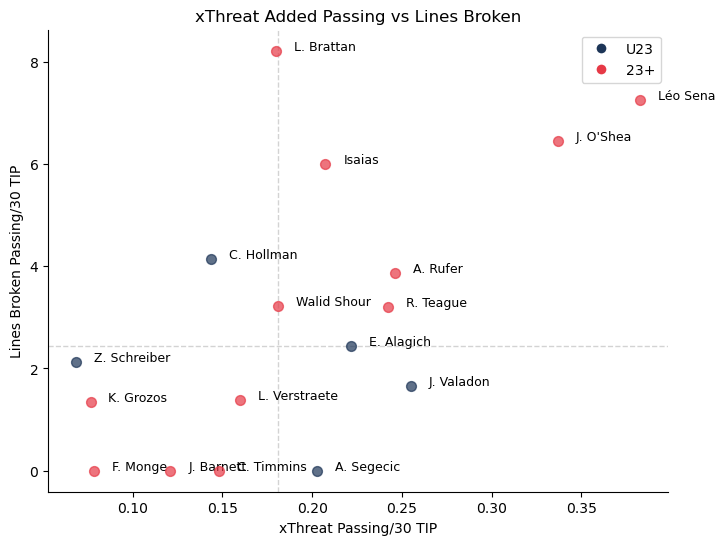

In [7]:
scatter = ASIProjViz(df).get_passing_value_scatter()

In order to scout midfielders with good passing ability, two types of passing are most important: progressive passing and final third creative passing. An initial graph with line breaking passing on the Y and xThreat passing on the x can display players who excel in one or both of these skills. Jay O'Shea and Léo Sena stand out as outliers in both, while Louis Brattan and Isaias are standout progressors who don't create much. Jordi Valadon is creative but not progressive, while Ryan Teague and Alex Rufer stand out in both categories. Let's dive deeper into various stats, though, to investigate each of these categories further.

**step by step narrow down**

/var/folders/hq/8f5kvgjd5dx23mthw16_z1lc0000gn/T/ipykernel_75886/1484047788.py:90: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


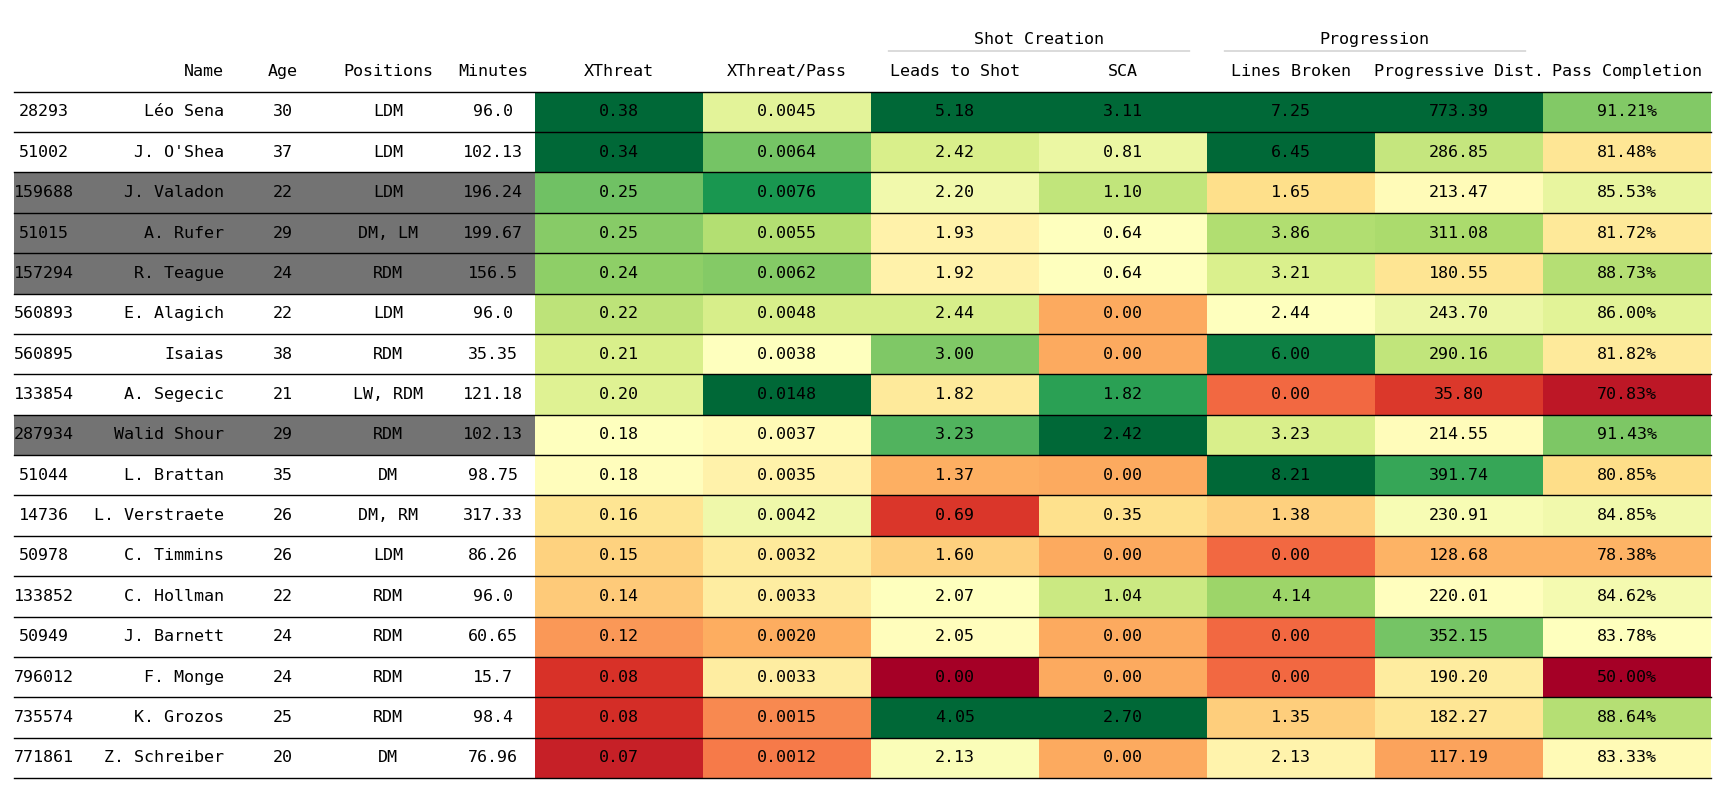

In [8]:
df = DataLoader(matchids).data_loader_multi_match()
summary = ASIProjMetrics(df).format_aggregator()
summary = StyleAggregator(summary).style_aggregator()
summary


Of the midfielders who created the most expected threat, Jay O'Shea is 37 and largely a set piece contributor, and Léo Sena is 30 and has a heart condition that may prevent him from ever playing again (https://tinyurl.com/2rtrzzxk). Ryan Teague, Alex Rufer, Walid Shour, and Jordi Valadon, however, display enticing numbers. Let's investigate these players further.



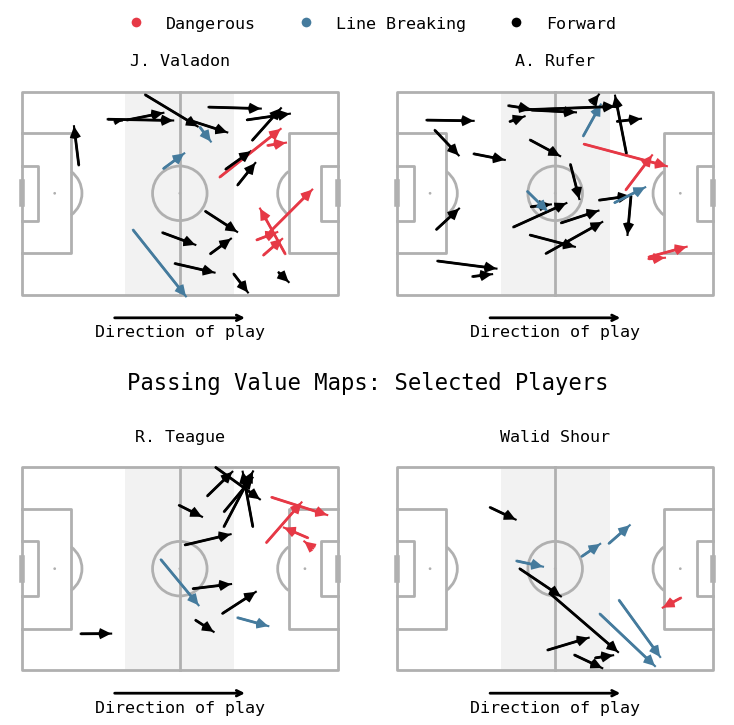

In [42]:


maps = ASIProjViz(df).get_multi_pass_maps([159688,51015,157294,287934])

**color coding**

**Plot9, cowpatch, clarify backword**
Looking at these passing value maps, Valadon and Rufer stand out. Valadon's contributions in the final third are the most incisive and dangerous, while Rufer is the most active in progressing play in deep and middle build up. Teague offers little in deep build up but contributes some in his half. Walid Shour barely shows up at all, perhaps indicating that his stellar metrics may have been due to volume or, in the case of SCA and passes leading to shot, high quality play from teammates.

Singling out Valadon and Rufer, lets look at each players' play outside of passing.

/var/folders/hq/8f5kvgjd5dx23mthw16_z1lc0000gn/T/ipykernel_75886/1484047788.py:809: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


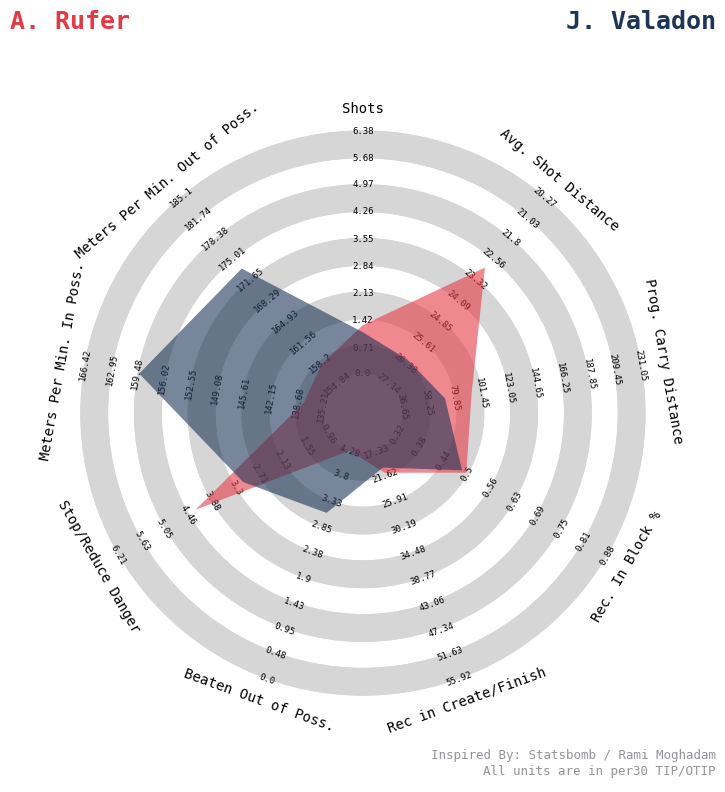

In [10]:
obj = ASIProjViz(df).get_non_passing_radar([51015,159688])

The radar chart tells us a few things. Valadon is a very active runner both in and out of possession, covering significant ground. Rufer, while running much less, is able to stop or reduce danger at a high clip, but is beaten out of possession the most in the dataset. Valadon is similar but slightly less aggressive. Neither player is a particularly active ballcarrier or shooter, but Valadon shoots from very far out on average which is a negative. Neither player recieves the ball particularly often, and often recieve outside the defensive block. 

Both players profile defensively as aggressive defenders rather than sitters, meaning they may not be suitable for a team looking for a very passive sitter to screen the defense. Valadon's running may be more useful in transition. Rufer may provide some shooting value, getting shots from decent positions at a reasonable clip (the shots wedge is skewed heavily by an outlier). 

Taking into account pass completion percentages and XThreat/pass from earlier, both players profile more as 8s than 6s in possession too. Both are very high in terms of XThreat per pass, indicating incisive passes in forward areas, and particularly Rufer has a very low completion percentage, indicating that they try difficult passes at a rate that might be too high risk for a 6 playing in front of the defense. This is particularly concerning for Rufer given how many of his valuable passes came in middle and defensive thirds. In this way, they are both much more similar to Adam Wharton than, say, Elliot Anderson.

Given Valadon is still 22 and provides serious value passing in the final third and some aggressive defending upside, he would be my recommendation for a team scouting Australia for a creative midfielder. Rufer might also be an option if his age (29) isn't prohibitive, and if a team is willing to accept his very aggressive defending and passing style. 

Of course, the main limitation here is the data. Even pretending that sample sizes are higher for the point of the exercise, the small sample constantly brought up outliers that skewed the analysis, particularly the radar (no deep midfielder should be able to average 6 shots per 30 TIP, for instance). **Sample size discussion** All code is written, however, to accept much more data and work with minimal alterations, given more data I could produce a much more accurate read. A more thorough analysis would also likely contain some sort of normalization or analysis of styles of play. **Expand context**